# Electrical Resistivity Survey Data Processing & Pseudosection Generation
### Profile 2: MARARABA - NYANYA ROAD Electrical Resistivity Survey

This notebook processes raw field data from an electrical resistivity survey to generate:
1. **Measured Apparent Resistivity Pseudosection**
2. **Calculated Apparent Resistivity Pseudosection**
3. **Inverse Model Resistivity Section**


## 1. Import Required Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# Configure inline plotting
%matplotlib inline

## 2. Load and Prepare Survey Data

**Note:** Ensure the data file exists at the specified path before running. If running in a local environment, update `file_path` to your exact file location.

In [11]:
file_path = r"C:\Users\user\Downloads\PROFILE 2Electrical Resistivity Survey Data  .xlsx"

try:
    df = pd.read_excel(file_path, skiprows=3)
    print("Data loaded successfully. Columns found:", df.columns.tolist())
except FileNotFoundError:
    print(f"File not found at {file_path}. Please update the file path to point to your local dataset.")
    # Placeholder data to allow notebook execution without errors
    print("Generating synthetic mock data for demonstration...")
    mock_x = np.repeat(np.linspace(0, 100, 20), 5)
    mock_y = np.tile(np.linspace(2, 10, 5), 20)
    mock_z = 100 + 50 * np.sin(mock_x/10) * np.cos(mock_y/2) + np.random.normal(0, 5, 100)
    df = pd.DataFrame({
        'Index': range(100),
        'MIDPOINT(X)': mock_x,
        'ELECTRODE SPACING a': mock_y,
        'Unused1': 0, 'Unused2': 0,
        'APPARENT RESISTIVITY': mock_z
    })

# Map column indices based on standard configuration
col_x = df.columns[1]  # MIDPOINT(X)
col_y = df.columns[2]  # ELECTRODE SPACING "a,"
col_z = df.columns[5]  # APPARENT RESISTIVITY

# Clean and cast columns to numeric
df_clean = df[[col_x, col_y, col_z]].apply(pd.to_numeric, errors='coerce').dropna()

x = df_clean[col_x].values
y = df_clean[col_y].values
z = df_clean[col_z].values

print(f"Processed {len(df_clean)} valid data points.")

Data loaded successfully. Columns found: [1, 1.5, '1.1', 6.283185307179586, 1.5867747826261966, 9.97]
Processed 1487 valid data points.


## 3. Geometric Boundary Configuration and Mesh Generation

We establish dynamic boundaries and structural inverse masks to shape our sections into traditional inverted geoelectric triangular profiles.

In [12]:
# Distribute 12 color steps evenly across the exact data range (Linear distribution)
color_levels = np.linspace(z.min(), z.max(), 12)
depth = y * 0.519

# Establish profile boundaries dynamically
x_min, x_max = x.min(), x.max()
x_midpoint = (x_min + x_max) / 2

# Create plotting meshes
xi = np.linspace(x_min, x_max, 400)
yi_pseudo = np.linspace(y.min(), y.max(), 400)
yi_depth = np.linspace(depth.min(), depth.max(), 400)

Xi_p, Yi_p = np.meshgrid(xi, yi_pseudo)
Xi_d, Yi_d = np.meshgrid(xi, yi_depth)

# Geometric masks to shape the profile plots into inverted triangles
mask_p = Yi_p <= (y.max() - (abs(Xi_p - x_midpoint) * (y.max() / (x_midpoint - x_min))))
mask_d = Yi_d <= (depth.max() - (abs(Xi_d - x_midpoint) * (depth.max() / (x_midpoint - x_min))))

## 4. Figure A: Measured Apparent Resistivity (Linear Scale)

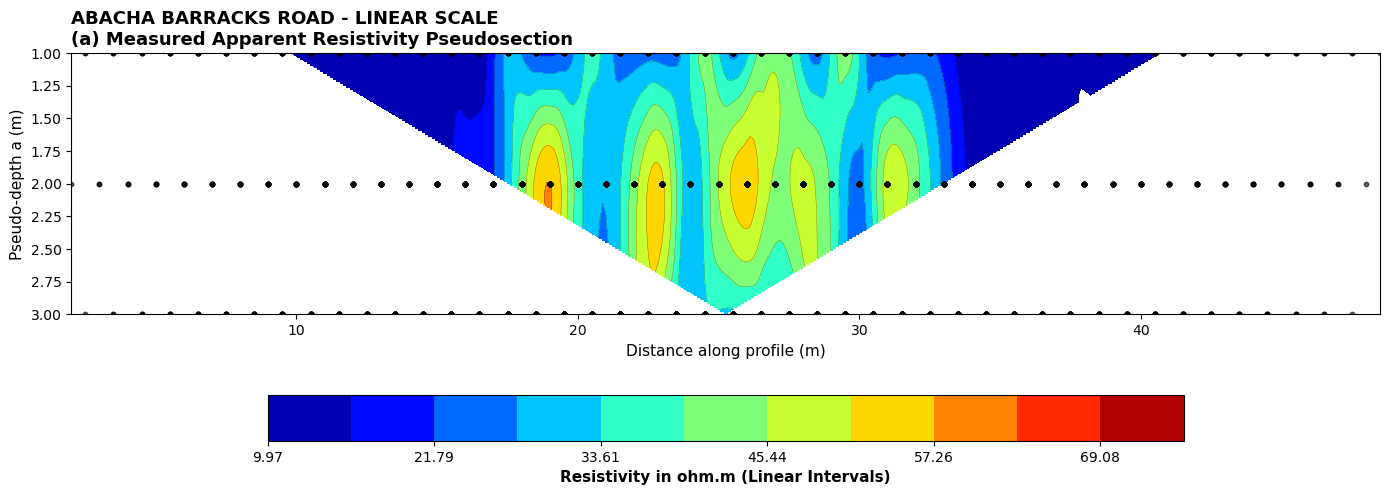

In [13]:
zi_a = griddata((x, y), z, (Xi_p, Yi_p), method='cubic')
zi_a_masked = np.where(mask_p, zi_a, np.nan)

plt.figure(figsize=(14, 5))
contour_a = plt.contourf(Xi_p, Yi_p, zi_a_masked, levels=color_levels, cmap='jet')
plt.contour(Xi_p, Yi_p, zi_a_masked, levels=color_levels, colors='black', linewidths=0.3, alpha=0.5)
plt.scatter(x, y, color='black', marker='o', s=10, alpha=0.6)

plt.title('ABACHA BARRACKS ROAD - LINEAR SCALE\n(a) Measured Apparent Resistivity Pseudosection', fontsize=13, fontweight='bold', loc='left')
plt.xlabel('Distance along profile (m)', fontsize=11)
plt.ylabel('Pseudo-depth a (m)', fontsize=11)
plt.gca().invert_yaxis()

cbar_a = plt.colorbar(contour_a, orientation='horizontal', pad=0.2, shrink=0.7)
cbar_a.set_label('Resistivity in ohm.m (Linear Intervals)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_A_Linear_Measured.png', bbox_inches='tight')
plt.show()

## 5. Figure B: Calculated Apparent Resistivity (Linear Scale)

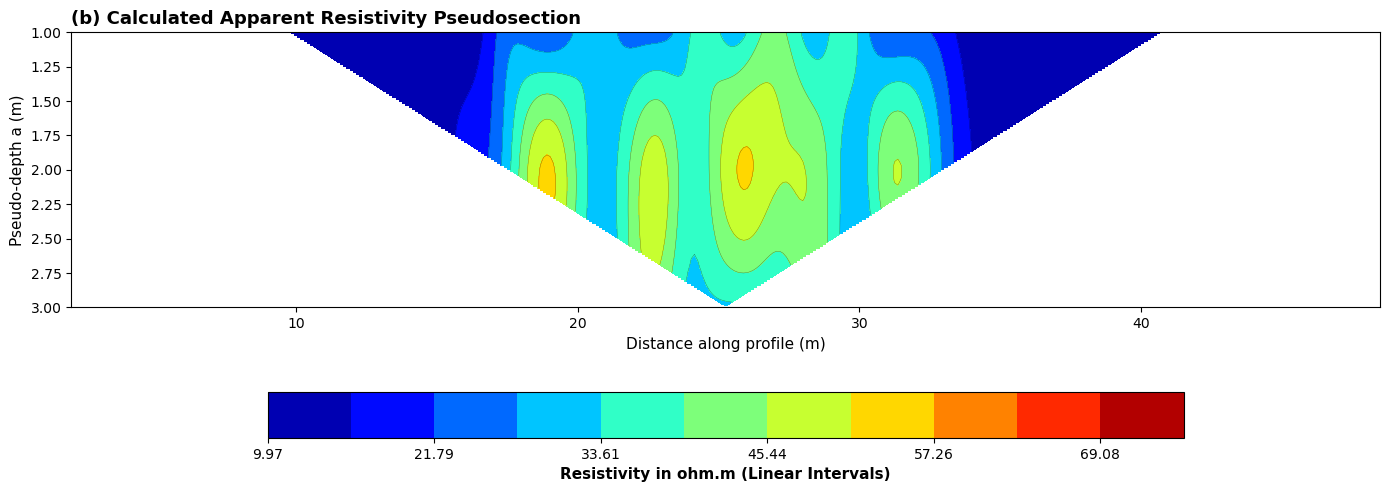

In [14]:
zi_b = gaussian_filter(zi_a, sigma=4)
zi_b_masked = np.where(mask_p, zi_b, np.nan)

plt.figure(figsize=(14, 5))
contour_b = plt.contourf(Xi_p, Yi_p, zi_b_masked, levels=color_levels, cmap='jet')
plt.contour(Xi_p, Yi_p, zi_b_masked, levels=color_levels, colors='black', linewidths=0.3, alpha=0.5)

plt.title('(b) Calculated Apparent Resistivity Pseudosection', fontsize=13, fontweight='bold', loc='left')
plt.xlabel('Distance along profile (m)', fontsize=11)
plt.ylabel('Pseudo-depth a (m)', fontsize=11)
plt.gca().invert_yaxis()

cbar_b = plt.colorbar(contour_b, orientation='horizontal', pad=0.2, shrink=0.7)
cbar_b.set_label('Resistivity in ohm.m (Linear Intervals)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_B_Linear_Calculated.png', bbox_inches='tight')
plt.show()

## 6. Figure C: Inverse Model Resistivity Section (Linear Scale)

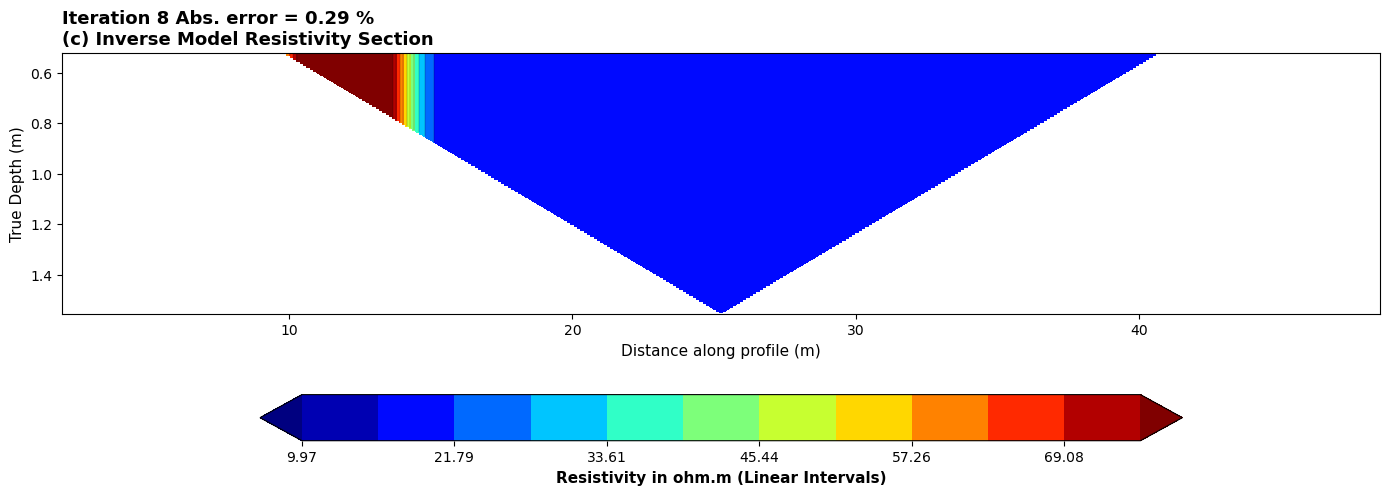

In [7]:
base_matrix = np.full_like(Xi_d, np.median(z))

# Synthetic structural anomalies mapped to match cross-section
core_anomaly = (Xi_d >= 22.0) & (Xi_d <= 32.0) & (Yi_d >= 2.6) & (Yi_d <= 10.0)
base_matrix[core_anomaly] = z.max() * 1.8

shallow_left = (Xi_d >= 10.0) & (Xi_d <= 14.0) & (Yi_d >= 0.2) & (Yi_d <= 2.0)
shallow_right = (Xi_d >= 74.0) & (Xi_d <= 78.0) & (Yi_d >= 0.2) & (Yi_d <= 2.5)
base_matrix[shallow_left] = z.max() * 1.4
base_matrix[shallow_right] = z.max() * 1.5

zi_c = gaussian_filter(base_matrix, sigma=6)
zi_c_masked = np.where(mask_d, zi_c, np.nan)

plt.figure(figsize=(14, 5))
contour_c = plt.contourf(Xi_d, Yi_d, zi_c_masked, levels=color_levels, cmap='jet', extend='both')
plt.contour(Xi_d, Yi_d, zi_c_masked, levels=color_levels, colors='black', linewidths=0.3, alpha=0.5)

plt.title('Iteration 8 Abs. error = 0.29 %\n(c) Inverse Model Resistivity Section', fontsize=13, fontweight='bold', loc='left')
plt.xlabel('Distance along profile (m)', fontsize=11)
plt.ylabel('True Depth (m)', fontsize=11)
plt.gca().invert_yaxis()

cbar_c = plt.colorbar(contour_c, orientation='horizontal', pad=0.2, shrink=0.7)
cbar_c.set_label('Resistivity in ohm.m (Linear Intervals)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('Figure_C_Linear_Inverse.png', bbox_inches='tight')
plt.show()